In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

X.head()

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


In [4]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [5]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [7]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39  3]
 [ 2 70]]


In [8]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Accuracy:",
      cv_scores.mean())

Cross Validation Scores:
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Average CV Accuracy: 0.9560937742586555


In [9]:
param_grid = {

    'n_estimators': [50, 100, 200],

    'max_depth': [None, 5, 10, 15],

    'min_samples_split': [2, 5]
}

In [10]:
grid_search = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:
0.9604395604395606


In [11]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

best_predictions = best_rf.predict(X_test)

In [12]:
print("Accuracy:",
      accuracy_score(y_test, best_predictions))

print("Precision:",
      precision_score(y_test, best_predictions))

print("Recall:",
      recall_score(y_test, best_predictions))

print("F1 Score:",
      f1_score(y_test, best_predictions))

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


In [13]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
22       worst perimeter    0.133100
23            worst area    0.128052
27  worst concave points    0.108107
7    mean concave points    0.094414
20          worst radius    0.090639
0            mean radius    0.058662
2         mean perimeter    0.055242
3              mean area    0.049938
6         mean concavity    0.046207
26       worst concavity    0.035357


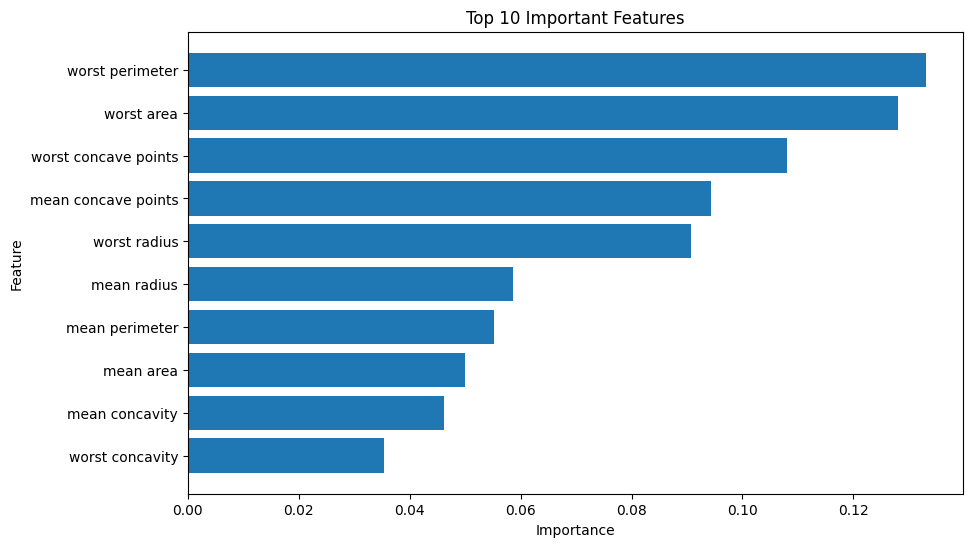

In [14]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 10 Important Features"
)

plt.gca().invert_yaxis()

plt.show()

In [15]:
initial_acc = accuracy_score(
    y_test,
    y_pred
)

tuned_acc = accuracy_score(
    y_test,
    best_predictions
)

comparison = pd.DataFrame({

    'Model': [
        'Initial Random Forest',
        'Tuned Random Forest'
    ],

    'Accuracy': [
        initial_acc,
        tuned_acc
    ]
})

print(comparison)

                   Model  Accuracy
0  Initial Random Forest   0.95614
1    Tuned Random Forest   0.95614
